[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giordamaug/Embed_Clinical_Sequences_Asplenic/blob/main/notebook.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/giordamaug/Embed_Clinical_Sequences_Asplenic/HEAD?urlpath=%2Fdoc%2Ftree%2Fnotebook.ipynb)

# Experiments

## Libraries

In [1]:
import torch
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
from sklearn.metrics import (
    matthews_corrcoef, confusion_matrix, accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
import lightgbm as lgb
import seaborn as sns
from tqdm.notebook import tqdm
import sys, os
import random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"       # to force BERT determinsm

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # per multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


## Download data from Github

In [2]:
try:
    import google.colab
    !git clone https:/github.com/giordamaug/Embed_Clinical_Sequences_Asplenic.git
    %cd Embed_Clinical_Sequences_Asplenic
    print("Working on Colab!")
except:
    pass

## Load dataset

In [3]:
df = pd.read_json(f"data/dataset_EN.json").set_index("id")
groupname = "ALL"
selected_ids = pd.read_csv(f"config/{groupname}_index.csv", header=None).values.ravel()
results_dir = "results"   # in "results_rev2" you find paper's results
niter = 2
num_epochs = 10
batch_size = 32
embedding_dim = 64
hidden_dim = 128
seed = 42
enable_plot = True
methods=['STATIC', 'BINARY', 'DOME', 'LSTM', 'tLSTM', 'GRU', 'GRU-D', 'BEHRT', 'RETAIN', 'Dipole']
methods=['LSTM', 'GRU', 'Dipole']
dataset = df.loc[selected_ids]
dataset

,is_splenectomized?,qt_vax_prophylaxis,days_after,days_before,qt_vax_post_prophylaxis,tsh,dosage_num,qt_vax_totali,smoking,dyslipidemia,...,splenectomy_indication,splenectomy_method,primary_disease,prophylaxis_vax_hib,prophylaxis_vax_flu,prophylaxis_vax_meningo,prophylaxis_vax_pneumo,splenectomy_response,gender,events
id,,,,,,,,,,,,,,,,,,,,,
1,1,0,0.0,0.0,5,NaN,-1000.0,4,0.0,0.0,...,NaN,0.0,2,0,0,0,0,NaN,0,"[{'type': 'therapy', 'event': 'antiplatelet ag..."
4,1,6,0.0,0.0,2,NaN,-1000.0,8,0.0,0.0,...,NaN,1.0,0,1,0,1,1,NaN,1,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
8,1,0,0.0,0.0,1,NaN,-1000.0,1,0.0,0.0,...,NaN,0.0,7,0,0,0,0,NaN,1,"[{'type': 'surgical operation', 'event': 'sple..."
9,1,3,0.0,0.0,1,NaN,-1000.0,4,0.0,0.0,...,NaN,0.0,2,1,0,1,1,NaN,0,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
10,1,3,0.0,0.0,0,NaN,-1000.0,3,0.0,0.0,...,NaN,0.0,0,1,0,1,1,NaN,0,"[{'type': 'therapy', 'event': 'anticoagulant',..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1948,1,11,0.0,0.0,0,NaN,-1000.0,11,0.0,0.0,...,NaN,NaN,0,1,0,1,1,NaN,1,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
1949,1,9,0.0,0.0,0,NaN,-1000.0,9,0.0,0.0,...,NaN,NaN,0,1,0,1,1,NaN,1,"[{'type': 'vaccination', 'event': 'PCV13', 'da..."
1950,1,9,0.0,0.0,0,NaN,-1000.0,9,0.0,0.0,...,NaN,NaN,0,1,0,1,1,NaN,1,"[{'type': 'vaccination', 'event': 'Hib', 'date..."


## Refine by subgroups

In [4]:
selected_ids = dataset.index
subgroup = ""   # no subgroup selection
if subgroup == "male":
    selected_ids = dataset[dataset["gender"] == 0].index.values
elif subgroup == "female":
    selected_ids = dataset[dataset["gender"] == 1].index.values
elif subgroup == "pediatric":
    selected_ids = dataset[dataset["age_group"] == 0].index.values
elif subgroup == "adolescent":
    selected_ids = dataset[dataset["age_group"] == 1].index.values
elif subgroup == "adult":
    selected_ids = dataset[dataset["age_group"] == 2].index.values
elif subgroup == "laparoscopy":
    selected_ids = dataset[dataset["splenectomy_method"] == 0.0].index.values
elif subgroup == "laparotomy":
    selected_ids = dataset[dataset["splenectomy_method"] == 1.0].index.values
dataset = df.loc[selected_ids]
dataset

,is_splenectomized?,qt_vax_prophylaxis,days_after,days_before,qt_vax_post_prophylaxis,tsh,dosage_num,qt_vax_totali,smoking,dyslipidemia,...,splenectomy_indication,splenectomy_method,primary_disease,prophylaxis_vax_hib,prophylaxis_vax_flu,prophylaxis_vax_meningo,prophylaxis_vax_pneumo,splenectomy_response,gender,events
id,,,,,,,,,,,,,,,,,,,,,
1,1,0,0.0,0.0,5,NaN,-1000.0,4,0.0,0.0,...,NaN,0.0,2,0,0,0,0,NaN,0,"[{'type': 'therapy', 'event': 'antiplatelet ag..."
4,1,6,0.0,0.0,2,NaN,-1000.0,8,0.0,0.0,...,NaN,1.0,0,1,0,1,1,NaN,1,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
8,1,0,0.0,0.0,1,NaN,-1000.0,1,0.0,0.0,...,NaN,0.0,7,0,0,0,0,NaN,1,"[{'type': 'surgical operation', 'event': 'sple..."
9,1,3,0.0,0.0,1,NaN,-1000.0,4,0.0,0.0,...,NaN,0.0,2,1,0,1,1,NaN,0,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
10,1,3,0.0,0.0,0,NaN,-1000.0,3,0.0,0.0,...,NaN,0.0,0,1,0,1,1,NaN,0,"[{'type': 'therapy', 'event': 'anticoagulant',..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1948,1,11,0.0,0.0,0,NaN,-1000.0,11,0.0,0.0,...,NaN,NaN,0,1,0,1,1,NaN,1,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
1949,1,9,0.0,0.0,0,NaN,-1000.0,9,0.0,0.0,...,NaN,NaN,0,1,0,1,1,NaN,1,"[{'type': 'vaccination', 'event': 'PCV13', 'da..."
1950,1,9,0.0,0.0,0,NaN,-1000.0,9,0.0,0.0,...,NaN,NaN,0,1,0,1,1,NaN,1,"[{'type': 'vaccination', 'event': 'Hib', 'date..."


## Get sequences and static data

In [5]:
from utils import count_events_by_type
ev_fields = ['event']
target_type = "infection"
events_field, date_field, type_field = 'events', 'date', 'type'
removeevents = ['followup', 'platelet_change']
target = 'eventi_infettivi'
attributes = pd.read_csv("config/attributes_EN.csv", header=None, comment = '#', index_col=0).index.to_list()
targets = pd.read_csv("config/targets_EN.csv", index_col=0)

event_sequences_no_trunc_with_type = { id: [(" ".join([event[field] for field in ev_fields]), event[date_field], event[type_field]) for event in events] for (id,events) in dataset[[events_field]].to_dict()[events_field].items()} 
cnt_df = count_events_by_type(event_sequences_no_trunc_with_type)

In [6]:
from utils import group_events_by_visit
# get sequence of event names
event_sequences_no_trunc_with_type = { id: [(" ".join([event[field] for field in ev_fields]), event[date_field], event[type_field]) for event in events if event[type_field] not in removeevents] for (id,events) in dataset[[events_field]].to_dict()[events_field].items()} 
event_sequences_no_trunc = { id: [(" ".join([event[field] for field in ev_fields]), event[date_field]) for event in events if event[type_field] not in removeevents] for (id,events) in dataset[[events_field]].to_dict()[events_field].items()} 
visit_sequences_no_trunc = group_events_by_visit(event_sequences_no_trunc)
print(f"n.{len(event_sequences_no_trunc)} Patients")


n.1067 Patients


## Get targets

In [7]:
targets = list(cnt_df.loc[target_type]['set'])
targets

['bacterial infection of the respiratory tract',
 'viral/automimetic infection of the eye',
 'bacterial infection of the gallbladder',
 'bacterial/viral infection of the joints',
 'bacterial infection of the breast',
 'bacterial/viral infection of the throat',
 'bacterial infection of the cardiovascular system',
 'bacterial infection of the bones',
 'viral infection',
 'bacterial infection of the urogenital system',
 'bacterial infection of the biliary tract',
 'systemic parasitic infection',
 'bacterial/viral infection of the gastrointestinal system',
 'bacterial infection of the urinary tract',
 'sexually transmitted viral infection',
 'autoimmune or inflammatory infection of the blood vessels',
 'bacterial/viral infection of the oral mucous membranes',
 'bacterial/viral infection of the central nervous system',
 'bacterial/viral infection of the ear',
 'bacterial infection of the gastrointestinal system',
 'viral infection of the skin and mucous membranes',
 'viral infection of the 

In [8]:
from utils import count_events_by_type
count_events_by_type(event_sequences_no_trunc_with_type)

,cardinality,n. instances,set
type,,,
therapy,34,3831,"{antiplatelet, antiplatelet aggregation, bone-..."
surgical operation,13,1129,"{cord surgery, appendectomy, splenectomy, pect..."
vaccination,8,4589,"{meningococcus_ACWY, Hib, meningococcus_C, PCV..."
infection,37,346,"{bacterial infection of the respiratory tract,..."
comorbidity,15,647,"{genetic and rare syndromes, endocrine and met..."
thrombosis,4,160,"{venous thrombosis, thromboembolism, arterial/..."


## Truncate sequences on 1st target

In [9]:
from utils import truncate_events_on1st_infection
event_sequences, y_df = truncate_events_on1st_infection(event_sequences_no_trunc_with_type, field_value=target_type)
visit_sequences = group_events_by_visit(event_sequences)

Truncating:   0%|          | 0/1067 [00:00<?, ?it/s]

## Configurations

In [10]:
from configure import configure_embedder

# === LSTM vocabulary ===
vocab = set()
for patient_events in event_sequences_no_trunc.values():
    for event,date in patient_events:
        vocab.update([event] if isinstance(event, str) else event)
word_to_idx = {word: idx for idx, word in enumerate(sorted(vocab))}  # for LSTM, RETAIN, etc
# === BEHRT vocabulary ===
code2id = {"[PAD]": 0, "[CLS]": 1, "[SEP]": 2}
idx = 3
for pid, visits in visit_sequences_no_trunc.items():
    for events, date in visits:
        for event in events:
            if event not in code2id:
                code2id[event] = idx
                idx += 1
labels = y_df.to_dict()['target']

embedder_configs = configure_embedder(event_sequences, event_sequences_no_trunc, visit_sequences, labels, targets, dataset,
                                        word_to_idx, code2id, vocab, attributes, num_epochs, batch_size, embedding_dim, hidden_dim, enable_plot)

In [10]:
from embedding import LSTMembedder, BEHRTembedder, COUNTEREmbedder, TimeAwareLSTMEmbedder, DipoleEmbedder 
from embedding import StaticEmbedder, RETAINembedder, DOMEEmbedder, BINARYEmbedder, GRUEmbedder, GRUEDembedder
# Definisci la lista dei "parametri" degli embedder
# === Vocabolario per LSTM ===
vocab = set()
for patient_events in event_sequences_no_trunc.values():
    for event,date in patient_events:
        vocab.update([event] if isinstance(event, str) else event)
word_to_idx = {word: idx for idx, word in enumerate(sorted(vocab))}  # for LSTM, RETAIN, etc
# === Vocabolario per BEHRT ===
code2id = {"[PAD]": 0, "[CLS]": 1, "[SEP]": 2}
idx = 3
for pid, visits in visit_sequences_no_trunc.items():
    for events, date in visits:
        for event in events:
            if event not in code2id:
                code2id[event] = idx
                idx += 1

labels = y_df.to_dict()['target']
embedder_configs =  { 
        "LSTM" : 
        {   "func": LSTMembedder,
            "kwargs": {
                "sequences": event_sequences,
                "labels": labels,
                "word_to_idx": word_to_idx,
                "num_epochs": num_epochs,
                "batch_size": batch_size,
                "embed_size": embedding_dim,
                "hidden_size": hidden_dim,
                "enable_plot": enable_plot
            }
        },
      "RETAIN" : 
        {   "func": RETAINembedder,
            "kwargs": {
                "sequences": visit_sequences,
                "labels": labels,
                "word_to_idx": code2id,
                "num_epochs": num_epochs,
                "batch_size": batch_size,
                "embed_size": embedding_dim,
                "hidden_size": hidden_dim,
                "enable_plot": enable_plot
            }
        },
      "BEHRT" : 
        {   "func": BEHRTembedder,
            "kwargs": {
                "sequences": visit_sequences,
                "labels": labels,
                "word_to_idx": code2id,
                "num_epochs": num_epochs,
                "batch_size": batch_size,
                "embed_size": embedding_dim,
                "hidden_size": hidden_dim,
                "enable_plot": enable_plot
            }
        },
      "Dipole" : 
        {   "func": DipoleEmbedder,
            "kwargs": {
                "sequences": event_sequences,
                "labels": labels,
                "word_to_idx": code2id,
                "num_epochs": num_epochs,
                "batch_size": batch_size,
                "embed_size": embedding_dim,
                "hidden_size": hidden_dim,
                "enable_plot": enable_plot
            }
        },
      "tLSTM" : 
        {   "func": TimeAwareLSTMEmbedder,
            "kwargs": {
                "sequences": event_sequences,
                "labels": labels,
                "word_to_idx": word_to_idx,
                "num_epochs": num_epochs,
                "batch_size": batch_size,
                "embed_size": embedding_dim,
                "hidden_size": hidden_dim,
                "enable_plot": enable_plot
            }
        },
       "GRU-D" : 
        {   "func": GRUEDembedder,
            "kwargs": {
                "sequences": visit_sequences,
                "labels": labels,
                "word_to_idx": code2id,
                "num_epochs": num_epochs,
                "batch_size": batch_size,
                "embed_size": embedding_dim,
                "hidden_size": hidden_dim,
                "enable_plot": enable_plot
            }
        },
      "GRU" : 
        {   "func": GRUEmbedder,
            "kwargs": {
                "sequences": event_sequences,
                "labels": labels,
                "word_to_idx": word_to_idx,
                "num_epochs": num_epochs,
                "batch_size": batch_size,
                "embed_size": embedding_dim,
                "hidden_size": hidden_dim,
                "enable_plot": enable_plot
            }
        },
      "STATIC" : 
        {   "func": StaticEmbedder,
            "kwargs": {
                "df": dataset,
                "include_attributes": attributes,
                "enable_plot": enable_plot
            }
        },
       "DOME" :
        {
            "func": DOMEEmbedder,
            "kwargs": {
                 "sequences": event_sequences_no_trunc,
                 "targets": targets,
                 "df": dataset,
                 "enable_plot": enable_plot
            }
        },
        "BINARY": 
        {
            "func": BINARYEmbedder,
            "kwargs": {
                "sequences": event_sequences,
                "vocab": vocab,
                "targets": targets,
                "enable_plot": enable_plot
            }
        },
        "COUNTER": 
        {
            "func": COUNTEREmbedder,
            "kwargs": {
                "sequences": event_sequences,
                "vocab": vocab,
                "targets": targets,
                "enable_plot": enable_plot
            }
        }
    }


## Iterated CV (Validation)

In [11]:
from cv_folding import lgbm_cv
import pickle
# Pre-allocate empty DataFrame with correct dtypes
results_df = pd.DataFrame()
rawcols = ['AUC', 'F1', 'Prec', 'Recall', 'MCC', 'Acc', 'Brier', 'CM', 'y_true_oof', 'y_pred_oof', 'y_prob_oof', 'calibration_prob_pred', 'calibration_prob_true']
res = {met: {m: [] for m in methods} for met in rawcols}
for i in range(int(niter)):
    for m in methods:
        set_seed(seed+i)
        results_tmp, model, _,_,_,_, results = lgbm_cv(embedder_configs, y_df, selected_ids, 
                                                       methods=["STATIC"] if m == 'STATIC' else ["STATIC", m], 
                                                       random_state=seed+i, return_metrics=True)
        for metric in res.keys():
            if metric in ['CM', 'y_true_oof', 'y_pred_oof', 'y_prob_oof', 'calibration_prob_pred', 'calibration_prob_true']:
                res[metric][m] += [results[metric].tolist()]
            elif metric == 'Brier':
                res[metric][m] += [results[metric]]
            else:
                res[metric][m] += results[metric]
        results_df = pd.concat([results_df, results_tmp],axis=0)
with open(f"{results_dir}/rawmeas_{niter}iter_{groupname}{subgroup}.pkl", 'wb') as f:
    pickle.dump(res, f)

for metric in res.keys():
    pd.DataFrame(res[metric]).to_csv(f"{results_dir}/resdata_{metric}_{groupname}.csv")
results_df.to_csv(f"{results_dir}/resdata_{niter}iter_{groupname}{subgroup}.csv")
results_df

,AUC mean,AUC std,F1 mean,F1 std,Prec mean,Prec std,Recall mean,Recall std,MCC mean,MCC std,Acc mean,Acc std,Brier,CM
STATIC+LSTM,0.800187,0.050324,0.645361,0.057579,0.790835,0.026457,0.547826,0.073271,0.585899,0.058528,0.871625,0.015955,0.122973,"[[804, 33], [104, 126]]"
STATIC+GRU,0.776916,0.066134,0.571443,0.103103,0.566174,0.119076,0.591304,0.134291,0.456388,0.130699,0.810710,0.042614,0.157738,"[[729, 108], [94, 136]]"
STATIC+Dipole,0.768460,0.060970,0.569849,0.093894,0.795315,0.061502,0.456522,0.117472,0.525536,0.079929,0.856614,0.019318,0.132738,"[[809, 28], [125, 105]]"
STATIC+LSTM,0.792071,0.040186,0.597023,0.079453,0.830471,0.053121,0.473913,0.092640,0.557182,0.069003,0.865034,0.018203,0.129663,"[[814, 23], [121, 109]]"
STATIC+GRU,0.763390,0.039348,0.605574,0.050741,0.652806,0.085591,0.573913,0.069565,0.510543,0.065594,0.838770,0.024730,0.140328,"[[763, 74], [98, 132]]"
STATIC+Dipole,0.774445,0.040970,0.589111,0.057205,0.690416,0.079653,0.517391,0.058977,0.505066,0.072405,0.844443,0.024024,0.133815,"[[782, 55], [111, 119]]"


### Print metrics mean std (Table 9-10)

In [19]:
dfs['AUC']

,LSTM,GRU,Dipole
0,0.780668,0.726967,0.737125
1,0.748124,0.798266,0.772904
2,0.838844,0.836436,0.762822
3,0.755272,0.675150,0.692463
4,0.878027,0.847761,0.876985
5,0.846079,0.826281,0.736542
6,0.818194,0.764752,0.776009
7,0.730409,0.703983,0.816064
8,0.766988,0.749935,0.720776
9,0.798685,0.771999,0.822833


In [16]:
import pandas as pd
import numpy as np
metrics = ['AUC', 'F1', 'Prec', 'Recall', 'MCC', 'Acc', 'CM', 'Brier']
dfs = {}
for p in metrics:
    dfs[p] = pd.read_csv(f"{results_dir}/resdata_{p}_{groupname}.csv", index_col=0)
    for m in dfs[p].columns:
        print(f"{m},", end='')
        if p == "CM":
                cm = dfs[p][m].apply(lambda x: np.array(eval(x))).sum() / 5
                print(f"{{{cm[0][0]}}}{{{cm[0][1]}}}{{{cm[1][0]}}}{{{cm[1][1]}}}" + "{N}{P}" + f"{{{float(cm[0][0])+float(cm[0][1])}}}{{{float(cm[1][0])+float(cm[1][1])}}}")
        else:
            None

for p in metrics:
    print(f"& {p} ", end='')
    dfs[p] = pd.read_csv(f"{results_dir}/resdata_{p}_{groupname}.csv", index_col=0)
print("\\\\")
for m in dfs[p].columns:
    print(f"{m} & ", end='')
    for p in metrics:
        if p == "CM":
                cm = dfs[p][m].apply(lambda x: np.array(eval(x))).sum() / 5
                print(f"\\cm{{{cm[0][0]}}}{{{cm[0][1]}}}{{{cm[1][0]}}}{{{cm[1][1]}}}" + "{N}{P}" + f"{{{float(cm[0][0])+float(cm[0][1])}}}{{{float(cm[1][0])+float(cm[1][1])}}} \\\\")
        else:
            print(f"{dfs[p][m].mean():.3f}$\pm${dfs[p][m].std():.3f} & ", end="")
pd.DataFrame(dfs)

LSTM,GRU,Dipole,LSTM,GRU,Dipole,LSTM,GRU,Dipole,LSTM,GRU,Dipole,LSTM,GRU,Dipole,LSTM,GRU,Dipole,LSTM,{323.6}{11.2}{45.0}{47.0}{N}{P}{334.8}{92.0}
GRU,{298.4}{36.4}{38.4}{53.6}{N}{P}{334.79999999999995}{92.0}
Dipole,{318.2}{16.6}{47.2}{44.8}{N}{P}{334.8}{92.0}
LSTM,GRU,Dipole,& AUC & F1 & Prec & Recall & MCC & Acc & CM & Brier \\
LSTM & 0.796$\pm$0.048 & 0.621$\pm$0.077 & 0.811$\pm$0.049 & 0.511$\pm$0.096 & 0.572$\pm$0.069 & 0.868$\pm$0.018 & \cm{323.6}{11.2}{45.0}{47.0}{N}{P}{334.8}{92.0} \\
0.126$\pm$0.005 & GRU & 0.770$\pm$0.058 & 0.589$\pm$0.088 & 0.609$\pm$0.118 & 0.583$\pm$0.113 & 0.483$\pm$0.113 & 0.825$\pm$0.040 & \cm{298.4}{36.4}{38.4}{53.6}{N}{P}{334.79999999999995}{92.0} \\
0.149$\pm$0.012 & Dipole & 0.771$\pm$0.055 & 0.579$\pm$0.083 & 0.743$\pm$0.093 & 0.487$\pm$0.103 & 0.515$\pm$0.081 & 0.851$\pm$0.024 & \cm{318.2}{16.6}{47.2}{44.8}{N}{P}{334.8}{92.0} \\
0.133$\pm$0.001 & 

ValueError: If using all scalar values, you must pass an index

# Model Explainability
## SHAP analysis

In [14]:
from cv_folding import lgbm_cv
results_df, model, X_df, Xv_df, y_train, y_test, results = lgbm_cv(embedder_configs, y_df, selected_ids, methods=["STATIC", "BINARY"], 
                                                                   random_state=seed, return_metrics=True)
results_df

,AUC mean,AUC std,F1 mean,F1 std,Prec mean,Prec std,Recall mean,Recall std,MCC mean,MCC std,Acc mean,Acc std,Brier,CM
STATIC+BINARY,0.848977,0.049291,0.683499,0.060926,0.740196,0.095589,0.643478,0.066793,0.608895,0.078758,0.870703,0.031119,0.116479,"[[781, 56], [82, 148]]"


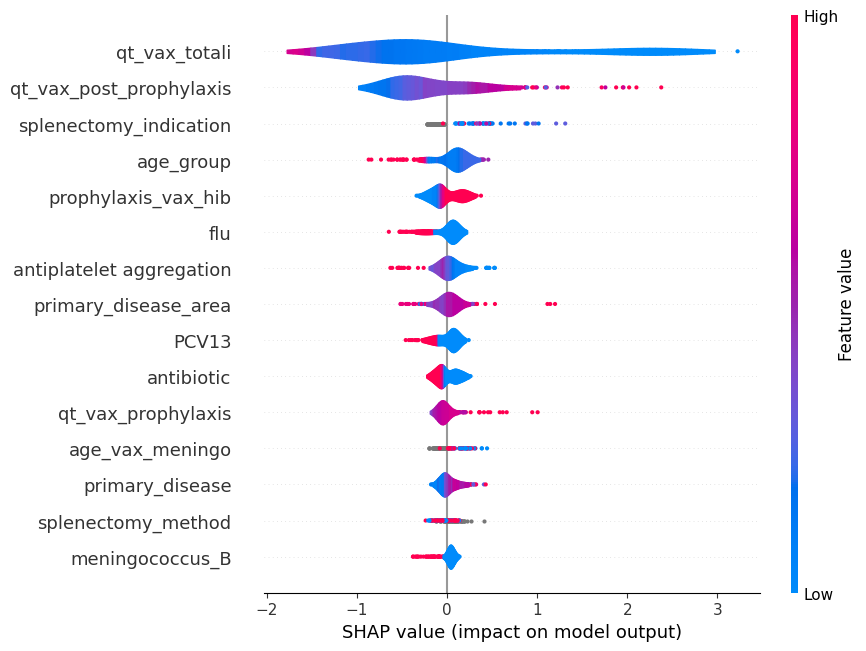

In [15]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer.shap_values(Xv_df)
shap.plots.violin(shap_values, features=Xv_df, feature_names=Xv_df.columns,max_display=15)


## Heatmaps

In [17]:
from cv_folding import lgbm_cv
results_df, model, X_df, Xv_df, y_train, y_test, results = lgbm_cv(embedder_configs, y_df, selected_ids, methods=["COUNTER"], 
                                                                   random_state=seed, return_metrics=True)
results_df

,AUC mean,AUC std,F1 mean,F1 std,Prec mean,Prec std,Recall mean,Recall std,MCC mean,MCC std,Acc mean,Acc std,Brier,CM
COUNTER,0.785143,0.067072,0.581998,0.103127,0.635624,0.081553,0.578261,0.170953,0.49422,0.087661,0.831315,0.021512,0.149049,"[[754, 83], [97, 133]]"


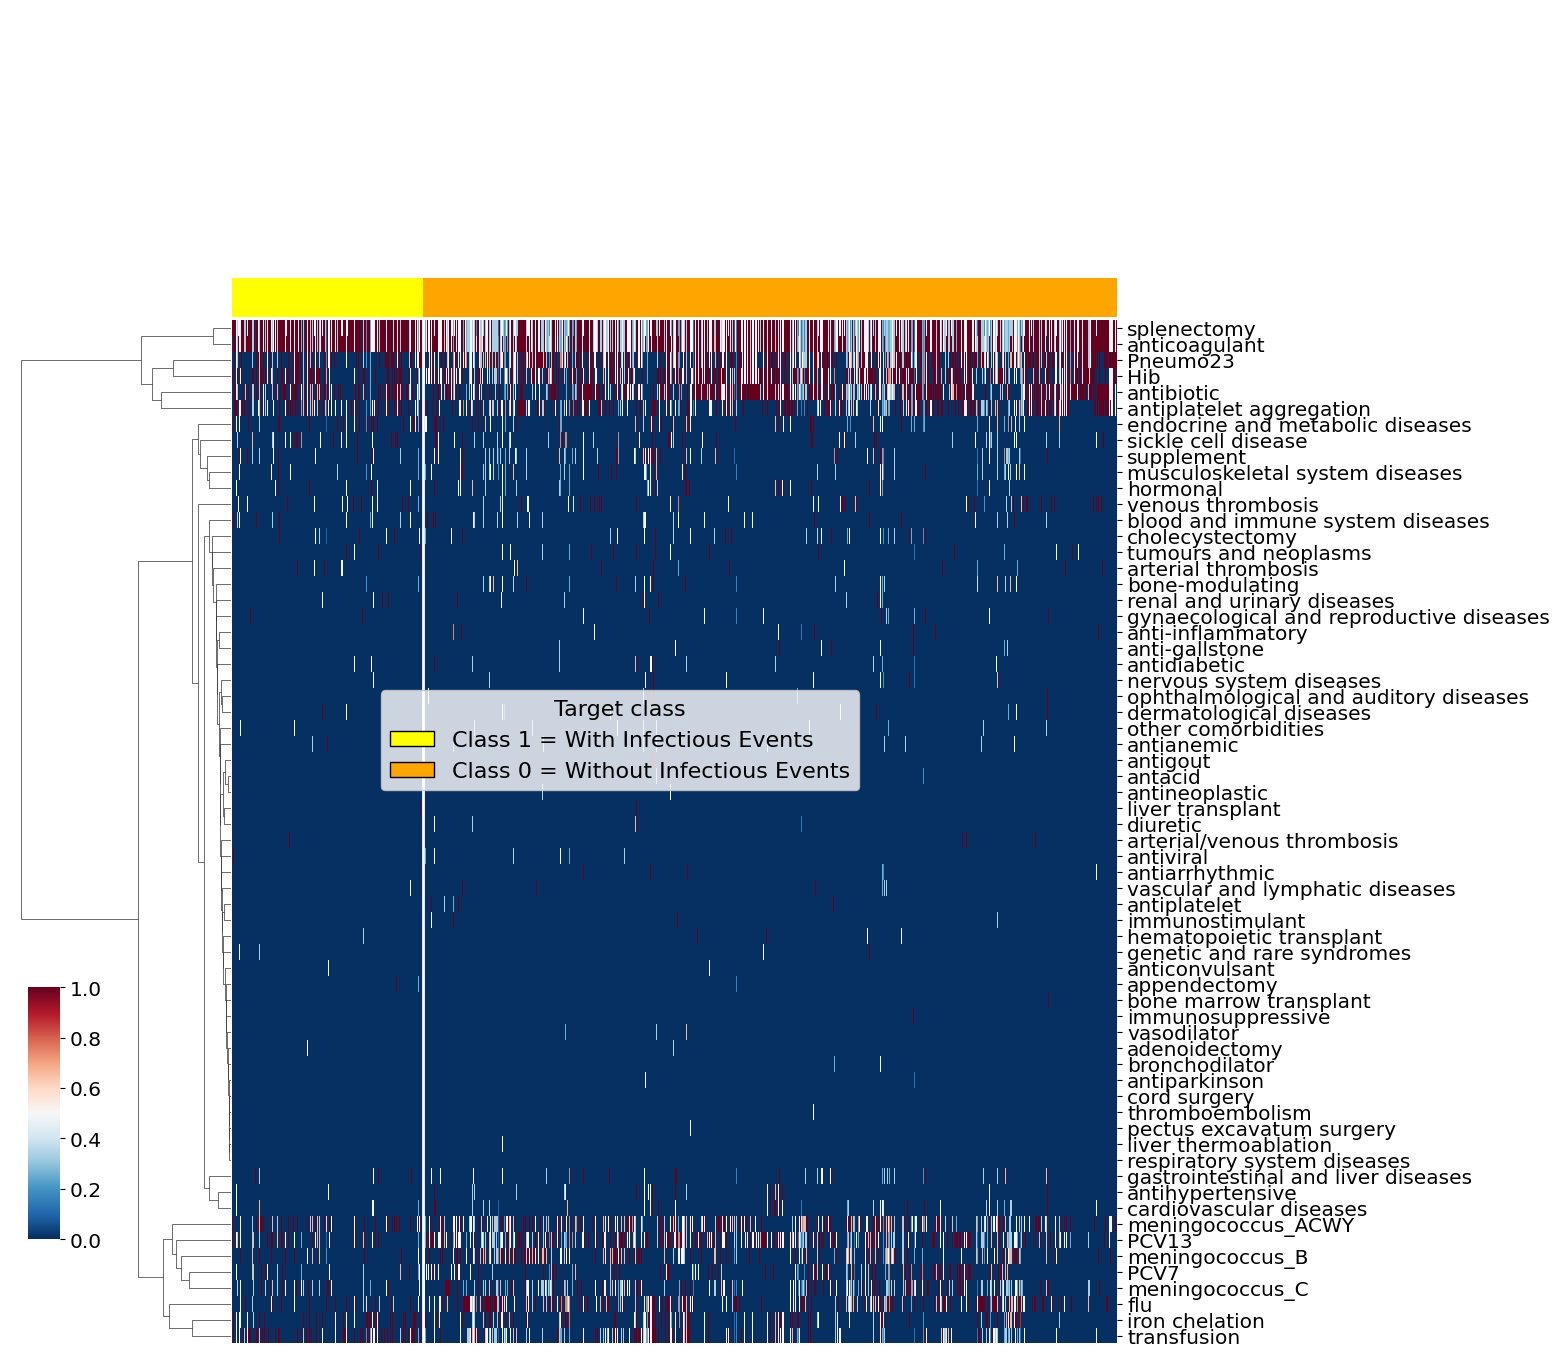

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
import matplotlib as mpl

mpl.rcParams['font.size'] = 20  # Dimensione base
mpl.rcParams['axes.titlesize'] = 22  # Titolo degli assi
mpl.rcParams['axes.labelsize'] = 22  # Etichette assi
mpl.rcParams['xtick.labelsize'] = 20  # Etichette asse x
mpl.rcParams['ytick.labelsize'] = 14.5  # Etichette asse y
mpl.rcParams['legend.fontsize'] = 16  # Font della legenda
mpl.rcParams['legend.title_fontsize'] = 16  # Titolo legenda

# Step 2: Rinomina le colonne nel DataFrame
X_df_traslated = pd.concat([X_df, Xv_df], axis=0)

# Aggiungi la colonna target temporaneamente per colorare le righe
X_df_traslated['target'] = y_df.loc[X_df_traslated.index, 'target']
X_sorted = X_df_traslated.sort_values('target', ascending=False)
targets_sorted = X_sorted['target'].values
X_sorted = X_sorted.drop(columns='target')


X_norm = X_sorted.copy()
X_norm_t = X_norm.T
scaler = MinMaxScaler()
X_norm_t.iloc[:, :] = scaler.fit_transform(X_norm_t)


# Applica la selezione sulle righe (trasponi, applica, poi ritrasponi)
X_filtered = X_norm_t[~(X_norm_t == 0).all(axis=1)]


# 2. (Facoltativo) Rimuovi righe duplicate
# len(X_final) = X_filtered.drop_duplicates()


# Crea una palette per distinguere classi (ad esempio 1=red, 0=blue)
row_colors = ['yellow' if y_df.loc[idx, 'target'] == 1 else 'orange' for idx in X_filtered.columns]


legend_elements = [Patch(facecolor='yellow', edgecolor='k', label='Class 1 = With Infectious Events'),
                   Patch(facecolor='orange', edgecolor='k', label='Class 0 = Without Infectious Events')]

g = sns.clustermap(
    X_filtered,
    cmap='RdBu_r',
    cbar_pos=(0.03, 0.1, 0.02, 0.18),
    figsize=(16, 14),
    col_colors=row_colors,
    xticklabels=False,
    yticklabels=True,
    col_cluster=False,
    row_cluster=True,
    metric='euclidean',
    method='ward'
)


# Calcola quante righe hanno target 1 (sono state messe in alto)
n_positive = sum(y_df.loc[X_filtered.columns, 'target'] == 1)

# Aggiungi linea orizzontale tra target 1 e 0
g.ax_heatmap.axvline(x=n_positive, color='white', linestyle='-', linewidth=2)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels())
# Aggiungi legenda
plt.gcf().legend(handles=legend_elements, title='Target class',
                 loc='upper center', bbox_to_anchor=(0.4, 0.5))
# plt.title("Clustered Heatmap (Sorted by Target)", pad=20)
plt.show()


# print("NaN totali:", X_filtered.isna().sum().sum())
# print("Inf totali:", np.isinf(X_filtered.to_numpy()).sum())
# X_norm_t.shape

# Statistical Analysis

In [33]:
import pandas as pd
import itertools
from scipy.stats import friedmanchisquare, wilcoxon
import statsmodels.stats.multitest as smm

# ======================
# LOAD DATA
# ======================
with open(f"{results_dir}/rawmeas_5iter_{groupname}{subgroup}.pkl", 'rb') as f:
    ff = pickle.load(f)
df = pd.DataFrame({m: ff['MCC'][m] for m in methods})
df

,BINARY,DOME,LSTM,tLSTM,GRU,GRU-D,BEHRT,RETAIN,Dipole
0,0.499222,0.600662,0.564022,0.315323,0.329376,0.501782,0.486353,0.444012,0.477263
1,0.627018,0.617657,0.520612,0.581635,0.508287,0.673367,0.616161,0.561393,0.546149
2,0.682480,0.711694,0.692932,0.618070,0.632701,0.711694,0.673066,0.588473,0.571059
3,0.537004,0.560338,0.556820,0.475426,0.282544,0.477054,0.377878,0.445457,0.400509
4,0.698752,0.714883,0.595108,0.560064,0.529033,0.707497,0.656950,0.570726,0.632701
5,0.634487,0.591303,0.534532,0.483678,0.612753,0.670206,0.566134,0.444861,0.523994
6,0.640010,0.662634,0.606549,0.543380,0.493753,0.607112,0.590464,0.486015,0.428815
7,0.528638,0.496178,0.455835,0.394291,0.413847,0.496854,0.554482,0.444637,0.495181
8,0.577627,0.542826,0.532044,0.503490,0.490005,0.656950,0.552641,0.465556,0.444637
9,0.624596,0.640267,0.656950,0.496014,0.542356,0.643501,0.535129,0.485896,0.632701


### Wiloxon pair-wise test

In [34]:
# ======================
# FRIEDMAN TEST
# ======================
stat, p = friedmanchisquare(*[df[col] for col in df.columns])

print("\n=== FRIEDMAN TEST ===")
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p:.6f}")

if p < 0.05:
    print("➡️ Differenze globali SIGNIFICATIVE")
else:
    print("➡️ Nessuna differenza globale")

alpha = 0.05

# ========================
# WILCOXON POST-HOC + HOLM
# ========================
pairs = list(itertools.combinations(df.columns, 2))

wilcoxon_raw_p = []
wilcoxon_results = []

for a, b in pairs:
    try:
        stawinst, pval = wilcoxon(df[a], df[b])
    except ValueError:
        stat, pval = None, 1.0
    wilcoxon_raw_p.append(pval)
    wilcoxon_results.append((a, b, stat, pval))

wilcoxon_reject, wilcoxon_p_corr, _, _ = smm.multipletests(
    wilcoxon_raw_p, alpha=alpha, method="holm"
)

print("\n" + "="*60)
print("WILCOXON PAIRWISE POST-HOC + HOLM")
print("="*60)

found_sig = False
for i, (a, b, stat, pval) in enumerate(wilcoxon_results):
    if wilcoxon_reject[i]:
        found_sig = True
        print(f"✅ {a} vs {b} | raw p = {pval:.6f} | Holm p = {wilcoxon_p_corr[i]:.6f}")

if not found_sig:
    print("wins❌ Nessuna coppia significativa dopo correzione Holm")

print("\nDettaglio completo Wilcoxon:")
for i, (a, b, stat, pval) in enumerate(wilcoxon_results):
    mark = "✅" if wilcoxon_reject[i] else "  "
    print(f"{mark} {a:>8s} vs {b:<8s} | raw p = {pval:.6f} | Holm p = {wilcoxon_p_corr[i]:.6f}")
import numpy as np

methods = list(df.columns)
n = len(methods)

# correct p-value matrix
p_matrix = np.ones((n, n))

# fill-in the matrix
k = 0
for i in range(n):
    for j in range(i+1, n):
        p_matrix[i, j] = wilcoxon_p_corr[k]
        p_matrix[j, i] = wilcoxon_p_corr[k]
        k += 1
pd.DataFrame(p_matrix, columns=methods, index = methods)


=== FRIEDMAN TEST ===
Statistic: 124.1788
p-value: 0.000000
➡️ Differenze globali SIGNIFICATIVE

WILCOXON PAIRWISE POST-HOC + HOLM
✅ BINARY vs LSTM | raw p = 0.002785 | Holm p = 0.030633
✅ BINARY vs tLSTM | raw p = 0.000000 | Holm p = 0.000002
✅ BINARY vs GRU | raw p = 0.000000 | Holm p = 0.000002
✅ BINARY vs BEHRT | raw p = 0.001155 | Holm p = 0.018477
✅ BINARY vs RETAIN | raw p = 0.000000 | Holm p = 0.000008
✅ BINARY vs Dipole | raw p = 0.000003 | Holm p = 0.000062
✅ DOME vs LSTM | raw p = 0.000120 | Holm p = 0.002404
✅ DOME vs tLSTM | raw p = 0.000000 | Holm p = 0.000005
✅ DOME vs GRU | raw p = 0.000000 | Holm p = 0.000004
✅ DOME vs BEHRT | raw p = 0.001453 | Holm p = 0.021791
✅ DOME vs RETAIN | raw p = 0.000000 | Holm p = 0.000004
✅ DOME vs Dipole | raw p = 0.000000 | Holm p = 0.000011
✅ LSTM vs tLSTM | raw p = 0.000103 | Holm p = 0.002163
✅ LSTM vs GRU | raw p = 0.000005 | Holm p = 0.000121
✅ LSTM vs GRU-D | raw p = 0.002025 | Holm p = 0.024302
✅ LSTM vs RETAIN | raw p = 0.000228

,BINARY,DOME,LSTM,tLSTM,GRU,GRU-D,BEHRT,RETAIN,Dipole
BINARY,1.000000,1.000000,0.030633,0.000002,0.000002,1.000000,0.018477,0.000008,0.000062
DOME,1.000000,1.000000,0.002404,0.000005,0.000004,1.000000,0.021791,0.000004,0.000011
LSTM,0.030633,0.002404,1.000000,0.002163,0.000121,0.024302,1.000000,0.003877,0.021791
tLSTM,0.000002,0.000005,0.002163,1.000000,0.638853,0.000002,0.003570,1.000000,1.000000
GRU,0.000002,0.000004,0.000121,0.638853,1.000000,0.000002,0.000039,1.000000,0.021791
GRU-D,1.000000,1.000000,0.024302,0.000002,0.000002,1.000000,0.003570,0.000002,0.000039
BEHRT,0.018477,0.021791,1.000000,0.003570,0.000039,0.003570,1.000000,0.000586,0.037809
RETAIN,0.000008,0.000004,0.003877,1.000000,1.000000,0.000002,0.000586,1.000000,0.681112
Dipole,0.000062,0.000011,0.021791,1.000000,0.021791,0.000039,0.037809,0.681112,1.000000


### Wilcoxon ranking (Win cout)

In [35]:
import pandas as pd

methods = list(df.columns)
n = len(methods)

# inizializza punteggi
wins = {m: 0 for m in methods}
losses = {m: 0 for m in methods}

k = 0
for i in range(n):
    for j in range(i+1, n):
        a = methods[i]
        b = methods[j]
        
        if wilcoxon_reject[k]:  # significativo
            # chi ha media maggiore?
            if df[a].mean() > df[b].mean():
                wins[a] += 1
                losses[b] += 1
            else:
                wins[b] += 1
                losses[a] += 1
        k += 1

# crea dataframe ranking
ranking_df = pd.DataFrame({
    "wins": wins,
    "losses": losses
})
ranking_df["score"] = ranking_df["wins"] - ranking_df["losses"]
ranking_df = ranking_df.sort_values(by="score", ascending=False)
ranking_df

,wins,losses,score
BINARY,6,0,6
DOME,6,0,6
GRU-D,6,0,6
LSTM,4,3,1
BEHRT,4,3,1
Dipole,1,5,-4
tLSTM,0,5,-5
RETAIN,0,5,-5
GRU,0,6,-6
